# Analysis

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Gold Layer Data

All tables are read from the CSV files produced by `gold_layer.ipynb`.

In [39]:
# ── USDA ──────────────────────────────────────────────────────────────
fact_usda          = pd.read_csv('../Medallion Architecture/data/gold_layer/USDA/fact_usda.csv')
dim_food_usda      = pd.read_csv('../Medallion Architecture/data/gold_layer/USDA/dim_food_usda.csv')
dim_category       = pd.read_csv('../Medallion Architecture/data/gold_layer/USDA/dim_category.csv')
dim_brand          = pd.read_csv('../Medallion Architecture/data/gold_layer/USDA/dim_brand.csv')
dim_datatype       = pd.read_csv('../Medallion Architecture/data/gold_layer/USDA/dim_datatype.csv')
dim_foodtype_usda  = pd.read_csv('../Medallion Architecture/data/gold_layer/USDA/dim_foodtype_usda.csv')
dim_healthscore_usda    = pd.read_csv('../Medallion Architecture/data/gold_layer/USDA/dim_healthscore_usda.csv')

# ── Healthy Foods ──────────────────────────────────────────────────────
fact_healthy_db      = pd.read_csv('../Medallion Architecture/data/gold_layer/healthyFoods/fact_healthy_db.csv')
dim_food_healthy     = pd.read_csv('../Medallion Architecture/data/gold_layer/healthyFoods/dim_food_healthy.csv')
dim_foodtype_healthy = pd.read_csv('../Medallion Architecture/data/gold_layer/healthyFoods/dim_foodtype_healthy.csv')
dim_healthscore   = pd.read_csv('../Medallion Architecture/data/gold_layer/healthyFoods/dim_healthscore.csv')

# Reconstruct healthy_db (fact joined back with dimension labels for analysis)
healthy_db = (
    fact_healthy_db
    .merge(dim_food_healthy,     on='FoodID',     how='left')
    .merge(dim_foodtype_healthy, on='FoodTypeID', how='left')
    .merge(dim_healthscore,    on='HealthScoreID', how='left')
)

# ── Allergens ──────────────────────────────────────────────────────────
fact_allergens    = pd.read_csv('../Medallion Architecture/data/gold_layer/allergens/fact_allergens.csv')
dim_product       = pd.read_csv('../Medallion Architecture/data/gold_layer/allergens/dim_product.csv')
dim_allergen_type = pd.read_csv('../Medallion Architecture/data/gold_layer/allergens/dim_allergen_type.csv')
dim_nutriscore    = pd.read_csv('../Medallion Architecture/data/gold_layer/allergens/dim_nutriscore.csv')
dim_nova          = pd.read_csv('../Medallion Architecture/data/gold_layer/allergens/dim_nova.csv')
dim_allergen_cat  = pd.read_csv('../Medallion Architecture/data/gold_layer/allergens/dim_allergen_cat.csv')

# Reconstruct allergens (fact joined back with dimension labels for analysis)
allergens = (
    fact_allergens
    .merge(dim_product,       on='ProductID',      how='left')
    .merge(dim_nutriscore,    on='NutriScoreID',   how='left')
    .merge(dim_nova,          on='NovaGroupID',    how='left')
    .merge(dim_allergen_type, on='AllergenTypeID', how='left')
    .merge(dim_allergen_cat,  on='AllergenCatID',  how='left')
)

# ── Cross-Dataset Merge: USDA × Healthy Foods ──────────────────────────────────────────────────────────────
merged_final          = pd.read_csv('../Medallion Architecture/data/gold_layer/merged_final.csv')

print('fact_usda:', fact_usda.shape)
print('healthy_db:        ', healthy_db.shape)
print('allergens:         ', allergens.shape)


fact_usda: (39997, 19)
healthy_db:         (8427, 13)
allergens:          (4926, 27)


# Dashboard 1: Nutrition Analysis (USDA)

### KPIs

| # | Metric | Description |
|---|--------|-------------|
| 1 | `avg_calories` | Average calories per product |
| 2 | `avg_protein` | Average protein (g) per product |
| 3 | `avg_fat` | Average fat (g) per product |
| 4 | `high_calories_ratio` | % of products with calories > 400 |
| 5 | `fiber_carb_ratio` | Average fiber-to-carb ratio |
| 6 | `protein_efficiency` | Average protein (g) per kcal |

In [40]:
# ── KPI 1: Average calories per product ─────────────────────────────
avg_calories = fact_usda['calories'].mean()
print(avg_calories)

# ── KPI 2: Average protein (g) per product ───────────────────────────
avg_protein = fact_usda['protein_g'].mean()
print(avg_protein)

# ── KPI 3: Average fat (g) per product ───────────────────────────────
avg_fat = fact_usda['fat_g'].mean()
print(avg_fat)

# ── KPI 4: % of products with calories > 400 ─────────────────────────
high_calories_ratio = (
    (fact_usda['calories'] > 400).mean()
) 
print(high_calories_ratio)

# ── KPI 5: Fiber-to-carb ratio (0 carbs replaced with NaN to avoid division error) ──
fiber_carb_ratio = (
    fact_usda['fiber_g'] /
    fact_usda['carbs_g'].replace(0, np.nan)
).mean()
print(fiber_carb_ratio)

# ── KPI 6: Protein efficiency — protein (g) per kcal ─────────────────
fact_usda['protein_per_kcal'] = (
    fact_usda['protein_g'] /
    fact_usda['calories'].replace(0, np.nan)
)
protein_efficiency = fact_usda['protein_per_kcal'].mean()
print(protein_efficiency)

252.94973373002975
8.248970695302146
12.075162327174539
0.2054404080306023
0.14662275830455926
0.04324638722784369


### Chart 1: Average Calories by Food Category

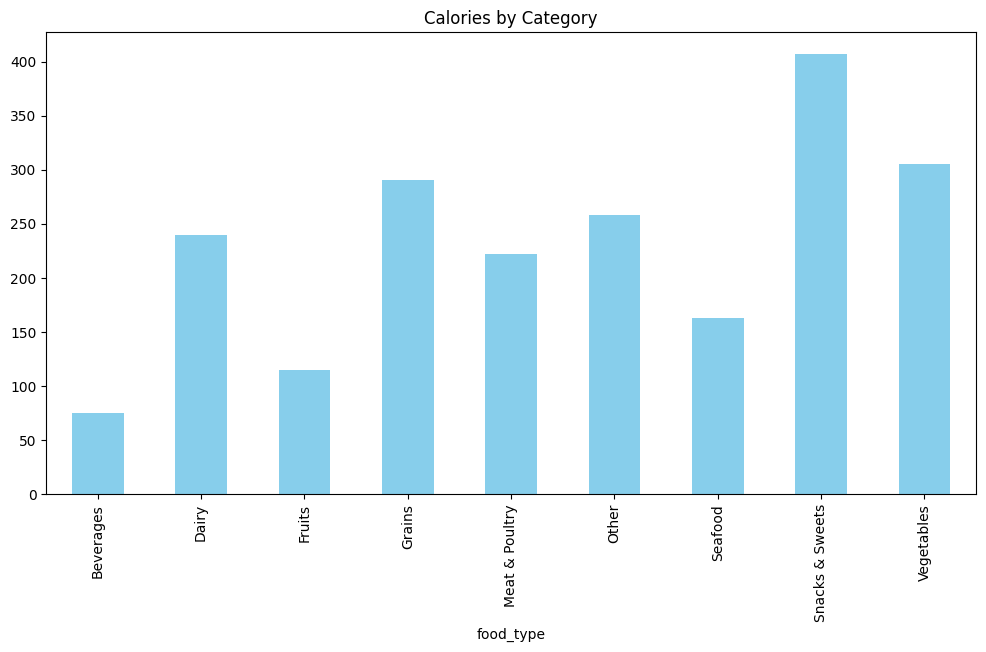

In [41]:
# Chart 1: Average Calories by Food Category

calories_by_category = (
    fact_usda
    .merge(dim_foodtype_usda, on='FoodTypeID')
    .groupby('food_type')['calories']
    .mean()
)

plt.figure(figsize=(12,6))

calories_by_category.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Calories by Category")

plt.show()

### Chart 2: Top 10 Highest-Calorie Products

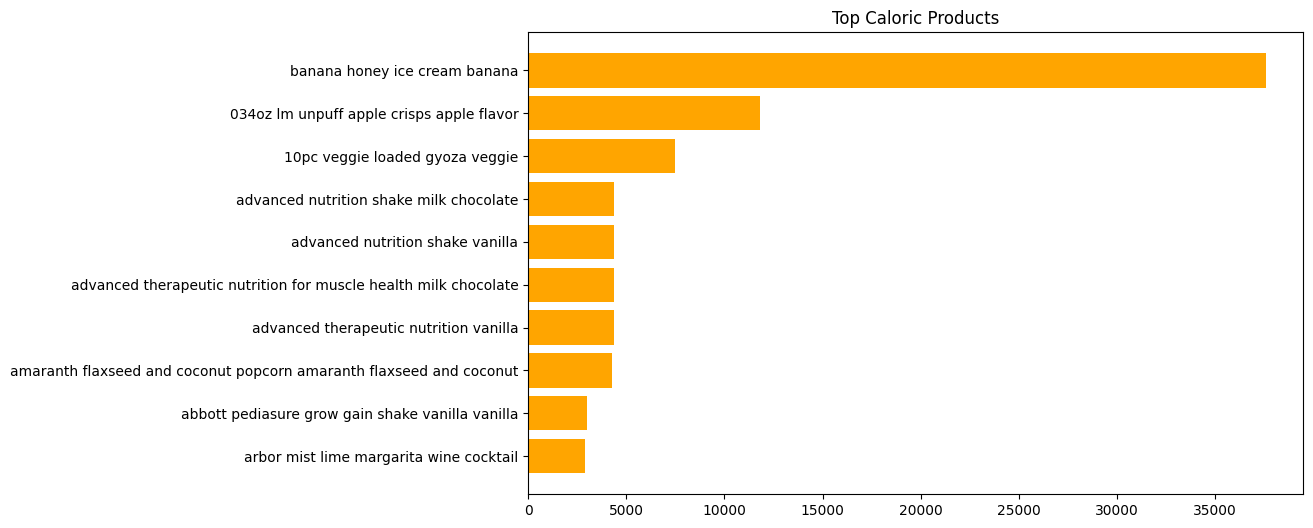

In [42]:
top_products = (
    fact_usda
    .merge(dim_food_usda, on='FoodID')
    .nlargest(10, 'calories')
)

plt.figure(figsize=(10,6))

plt.barh(
    top_products['food_name'],
    top_products['calories'],
    color='orange'
)

plt.gca().invert_yaxis()

plt.title("Top Caloric Products")

plt.show()

### Chart 3: Fat vs. Calories Scatter Plot

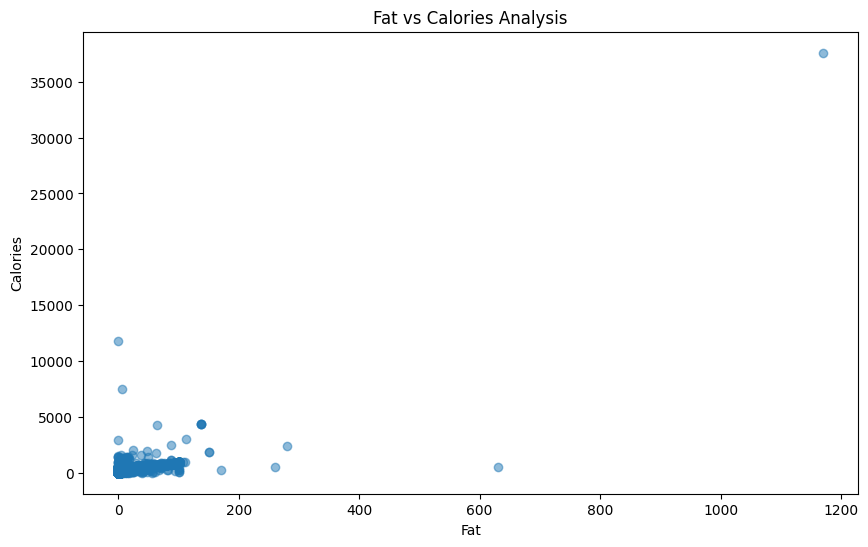

In [43]:
plt.figure(figsize=(10,6))

plt.scatter(
    fact_usda['fat_g'],
    fact_usda['calories'],
    alpha=0.5
)

plt.title("Fat vs Calories Analysis")
plt.xlabel("Fat")
plt.ylabel("Calories")

plt.show()

### Chart 4: Product Count Distribution by Category

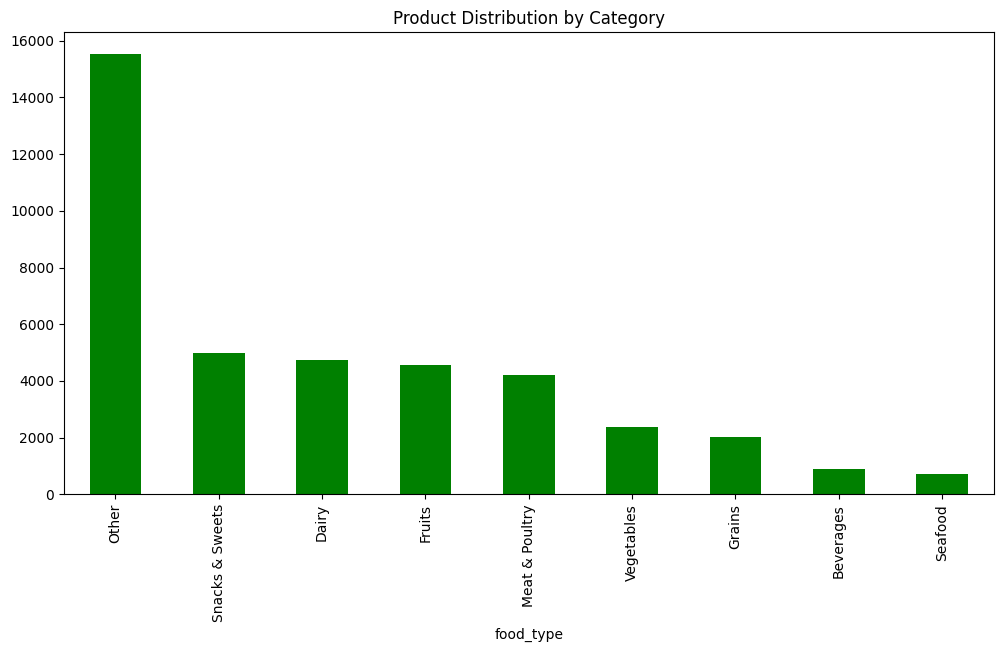

In [44]:
category_counts = (
    fact_usda
    .merge(dim_foodtype_usda, on='FoodTypeID')
    ['food_type']
    .value_counts()
)

plt.figure(figsize=(12,6))

category_counts.plot(
    kind='bar',
    color='green'
)

plt.title("Product Distribution by Category")

plt.show()

### Filter 1: Filter by Brand Name

Change `brand_filter` to any brand in the dataset.

In [45]:
brand_filter = "Nestle"

filtered_brand = (
    fact_usda
    .merge(dim_brand, on='BrandID')
    .query("brand_name == @brand_filter")
)

display(filtered_brand.head())

,fdc_id,FoodID,CategoryID,BrandID,DataTypeID,FoodTypeID,HealthScoreID,calories,carbs_g,fat_g,...,fiber_g,sodium_mg,calcium_mg,iron_mg,saturated_fat_g,vitamin_c_mg,cholesterol_mg,protein_per_kcal,brand_owner,brand_name


### Filter 2: Filter by Food Category

Change `category_filter` to any category in the dataset.

In [46]:
category_filter = "Snacks"

filtered_category = (
    fact_usda
    .merge(dim_category, on='CategoryID')
    .query("food_category == @category_filter")
)

display(filtered_category.head())

,fdc_id,FoodID,CategoryID,BrandID,DataTypeID,FoodTypeID,HealthScoreID,calories,carbs_g,fat_g,...,sugar_g,fiber_g,sodium_mg,calcium_mg,iron_mg,saturated_fat_g,vitamin_c_mg,cholesterol_mg,protein_per_kcal,food_category
2039,167734,2025,22,1,1,1,5,376.0,72.8,7.5,...,35.10,2.1,337.0,41.0,4.86,1.50,0.0,0.0,0.011702,Snacks
2040,169063,2026,22,1,1,9,5,464.4,66.7,17.6,...,27.50,3.1,251.0,60.0,3.18,12.70,1.0,0.0,0.021102,Snacks
2602,168860,2582,22,1,1,7,2,432.5,72.4,12.1,...,7.29,3.6,842.0,357.0,1.28,2.10,21.4,1.0,0.019653,Snacks
3909,173149,3871,22,1,1,9,3,389.0,69.8,10.0,...,25.00,22.5,237.0,250.0,0.90,3.40,1.2,0.0,0.012853,Snacks
3910,174787,3872,22,1,1,9,2,403.0,52.5,12.2,...,16.90,4.3,386.0,886.0,14.20,5.52,68.0,0.0,0.051613,Snacks


### Filter 3: Filter by Food Type

Change `food_type_filter` to any food type in the dataset.

In [47]:
food_type_filter = "snacks"

filtered_food_type = (
    fact_usda
    .merge(dim_foodtype_usda, on='FoodTypeID')
    .query("food_type == @food_type_filter")
)

display(filtered_food_type.head())

,fdc_id,FoodID,CategoryID,BrandID,DataTypeID,FoodTypeID,HealthScoreID,calories,carbs_g,fat_g,...,sugar_g,fiber_g,sodium_mg,calcium_mg,iron_mg,saturated_fat_g,vitamin_c_mg,cholesterol_mg,protein_per_kcal,food_type


---
# Dashboard 2: Health Score Analysis

### KPIs

| # | Metric | Description |
|---|--------|-------------|
| 1 | `avg_health` | Average health score across all products |
| 2 | `high_health` | % of products with health score ≥ 70 |
| 3 | `low_health` | % of products with health score < 62 |
| 4 | `active_health_tiers` | Number of distinct health tiers (Low / Medium / High) |
| 5 | `health_performance_index` | Average health score divided by average calories |

In [48]:
# ── KPI 1: Average health score ─────────────────────────────────────
avg_health = dim_healthscore['health_score'].mean()
print(avg_health)

# ── KPI 2: % of products with health score >= 70 (high tier) ────────
high_health = (
    (dim_healthscore['health_score'] >= 70).mean()
) 
print(high_health)

# ── KPI 3: % of products with health score < 60 (low tier) ──────────
low_health = (
    (dim_healthscore['health_score'] < 62).mean()
) 
print(low_health)

# ── KPI 4: Number of distinct health tiers ───────────────────────────
def categorize(score):
    if score >= 70:
        return 'High'
    elif score >= 62:
        return 'Medium'
    else:
        return 'Low'

dim_healthscore['health_category'] = dim_healthscore['health_score'].apply(categorize)
active_health_tiers = dim_healthscore['health_category'].nunique()
print(active_health_tiers)

# ── KPI 5: Health Performance Index — avg health score / avg calories ─
health_performance_index = (
    dim_healthscore['health_score'].mean() /
    healthy_db['calories'].mean()
)
print(health_performance_index)

67.5
0.5
0.25
3
0.25919525789864933


### Chart 1: Health Score Distribution

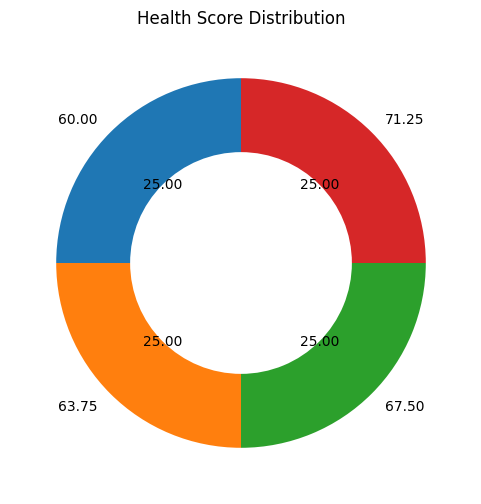

In [49]:
# Draw Health Score distribution as a Donut Chart with 4 bins
plt.figure(figsize=(6, 6))

# Divide data into 4 bins and calculate frequency
counts, bin_edges, patches = plt.hist(dim_healthscore['health_score'], bins=4)

# Prepare labels (starting values of each bin)
labels = [f"{bin_edges[i]:.2f}" for i in range(len(bin_edges)-1)]

# Draw the Donut Chart
plt.clf()  # Clear temporary histogram

plt.pie(
    counts,
    labels=labels,
    startangle=90,
    wedgeprops={'width': 0.4},   # Converts pie into donut
    autopct='%1.2f'
)

plt.title("Health Score Distribution")
plt.show()

### Chart 2: Average Calories by Food Type (Trend View)

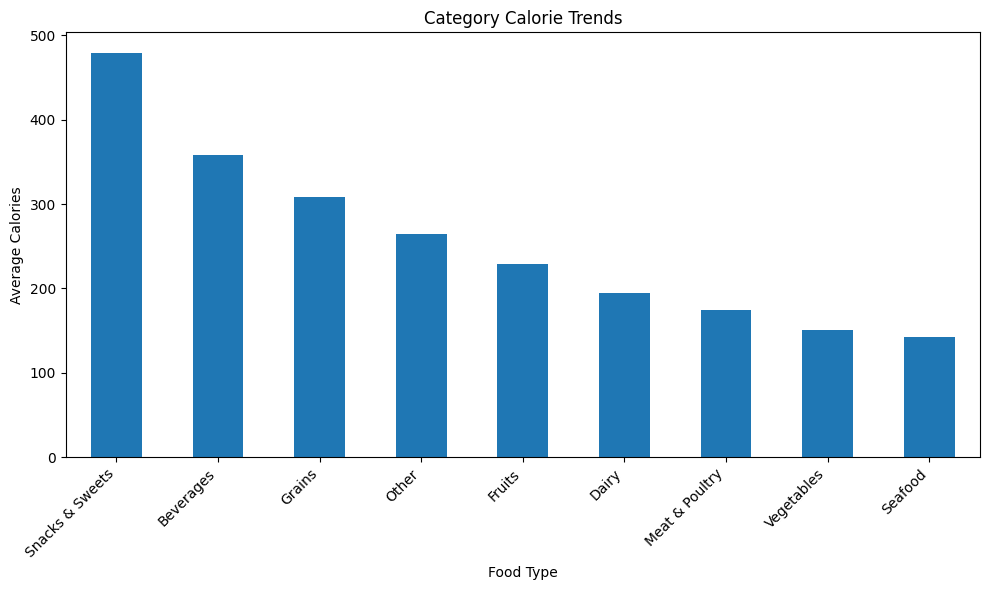

In [50]:
# Average calories by food type
category_calories = (
    healthy_db
    .groupby('food_type')['calories']
    .mean()
    .sort_values(ascending=False)
)

# Column chart
plt.figure(figsize=(10,6))

category_calories.plot(
    kind='bar',      # column chart
)

# Titles
plt.title("Category Calorie Trends")
plt.xlabel("Food Type")
plt.ylabel("Average Calories")

# Rotate labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Chart 3: Average Sugar Content by Food Type

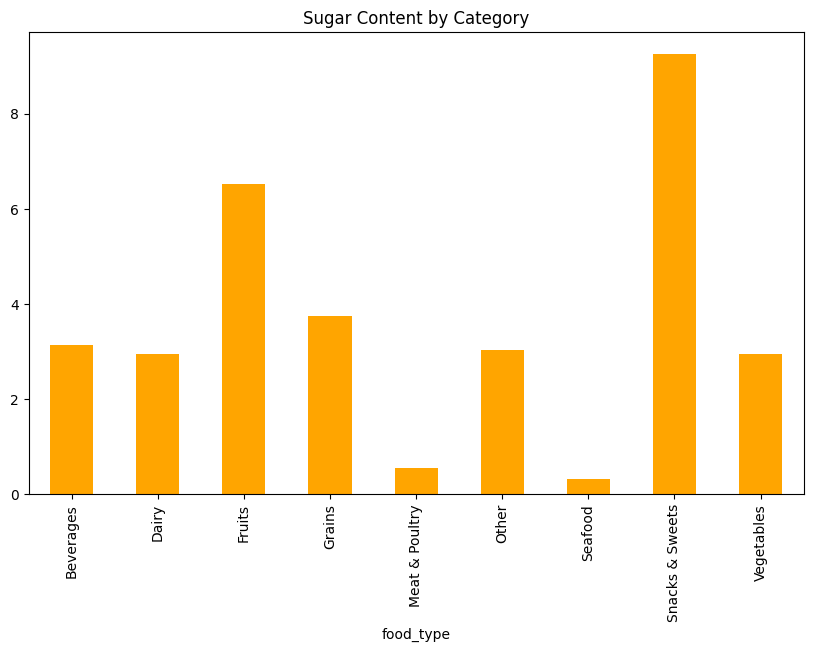

In [51]:
sugar_by_category = (
    healthy_db
    .groupby('food_type')['sugar_g']
    .mean()
)

plt.figure(figsize=(10,6))

sugar_by_category.plot(
    kind='bar',
    color='orange'
)

plt.title("Sugar Content by Category")

plt.show()

### Chart 4: Sodium & Sugar Cumulative View

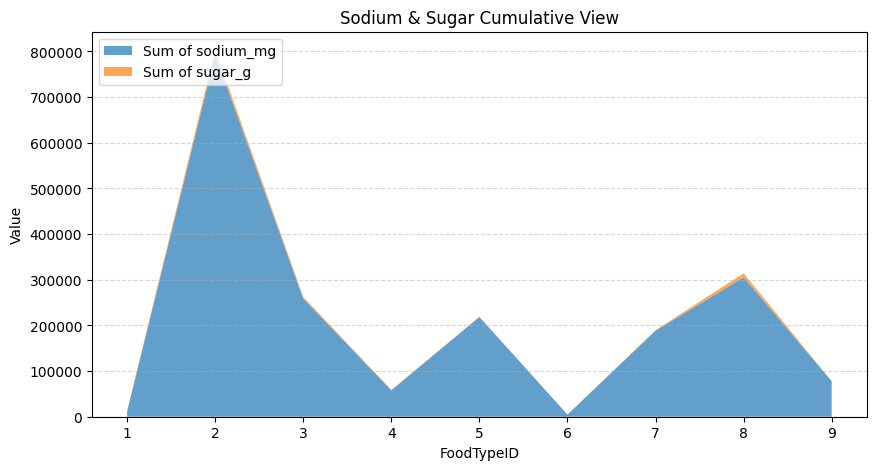

In [52]:
# Group data by FoodTypeID
grouped = (
    fact_healthy_db .groupby('FoodTypeID')[['sodium_mg', 'sugar_g']]
    .sum()
    .reset_index()
)

# Create the chart
plt.figure(figsize=(10, 5))

# Draw Stacked Area Chart
plt.stackplot(
    grouped['FoodTypeID'],
    grouped['sodium_mg'],
    grouped['sugar_g'],
    labels=['Sum of sodium_mg', 'Sum of sugar_g'],
    alpha=0.7
)

# Format the chart
plt.title('Sodium & Sugar Cumulative View')
plt.xlabel('FoodTypeID')
plt.ylabel('Value')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Filter 1: Filter by Food Type

Change `food_type_filter` to any food type in the dataset.

In [53]:
food_type_filter = "snacks"

filtered_food_type = healthy_db[
    healthy_db['food_type'] == food_type_filter
]

display(filtered_food_type.head())

,FoodID,FoodTypeID,HealthScoreID,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,food_name,food_type,health_score


### Filter 2: Filter by Health Score Range

Currently shows products with health score in [60, 70). Adjust bounds as needed.

In [54]:
filtered_health_score = healthy_db[
    (healthy_db['health_score'] >= 60) &
    (healthy_db['health_score'] < 70)
]

display(filtered_health_score.head())

,FoodID,FoodTypeID,HealthScoreID,calories,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,food_name,food_type,health_score
0,1,1,1,69.0,1.50,0.10,17.60,5.3,8.55,20.0,abiyuch raw,Fruits,65
1,2,2,2,68.0,0.52,0.15,16.20,6.6,2.58,14.0,agave raw southwest,Other,60
4,5,2,2,156.8,12.60,9.79,4.57,1.4,2.27,381.0,applebees chili,Other,60
5,6,1,2,113.0,1.17,0.15,29.30,4.1,4.88,3.0,apricots dried sulfured stewed with added sugar,Fruits,60
6,7,3,2,357.0,0.30,0.10,88.20,3.4,3.52,2.0,arrowroot flour,Grains,60


---
# Dashboard 3: Allergens Analysis

### KPIs

| # | Metric | Description |
|---|--------|-------------|
| 1 | `gluten_ratio` | % of products containing gluten |
| 2 | `dairy_ratio` | % of products containing dairy |
| 3 | `nuts_ratio` | % of products containing nuts |
| 4 | `soy_ratio` | % of products containing soy |
| 5 | `fish_ratio` | % of products containing fish |
| 6 | `safe_products_percentage` | % of products free from all 6 tracked allergens |

In [55]:
# ── KPI 1–5: % of products containing each allergen ─────────────────
gluten_ratio = allergens['contains_gluten'].mean() * 100
print(gluten_ratio)

dairy_ratio = allergens['contains_dairy'].mean() * 100
print(dairy_ratio)

nuts_ratio = allergens['contains_nuts'].mean() * 100
print(nuts_ratio)

soy_ratio = allergens['contains_soy'].mean() * 100
print(soy_ratio)

fish_ratio = allergens['contains_fish'].mean() * 100
print(fish_ratio)

# ── KPI 6: % of products free from all 6 tracked allergens ──────────
safe_products = allergens[
    (allergens['contains_gluten'] == 0) &
    (allergens['contains_dairy'] == 0) &
    (allergens['contains_nuts'] == 0) &
    (allergens['contains_soy'] == 0) &
    (allergens['contains_eggs'] == 0) &
    (allergens['contains_fish'] == 0)
]

safe_products_percentage = (
    len(safe_products) / len(allergens)
) * 100
print(safe_products_percentage)

32.298010556232235
30.085261875761265
11.855460820138044
17.133576938692652
2.2736500203004466
37.393422655298416


### Chart 1: Safe vs. Unsafe Products (Pie Chart)

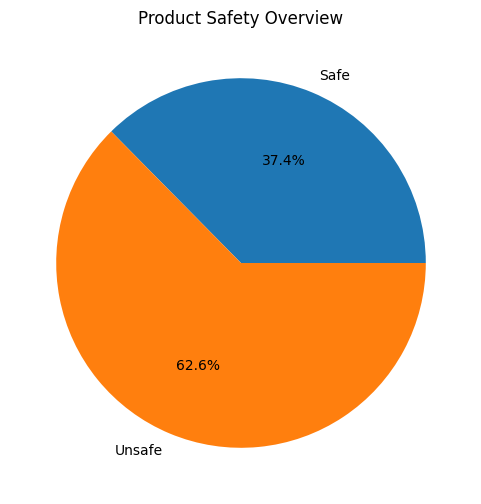

In [56]:
labels = ['Safe', 'Unsafe']

values = [
    len(safe_products),
    len(allergens) - len(safe_products)
]

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Product Safety Overview")

plt.show()

### Chart 2: Allergen Count Distribution per Product

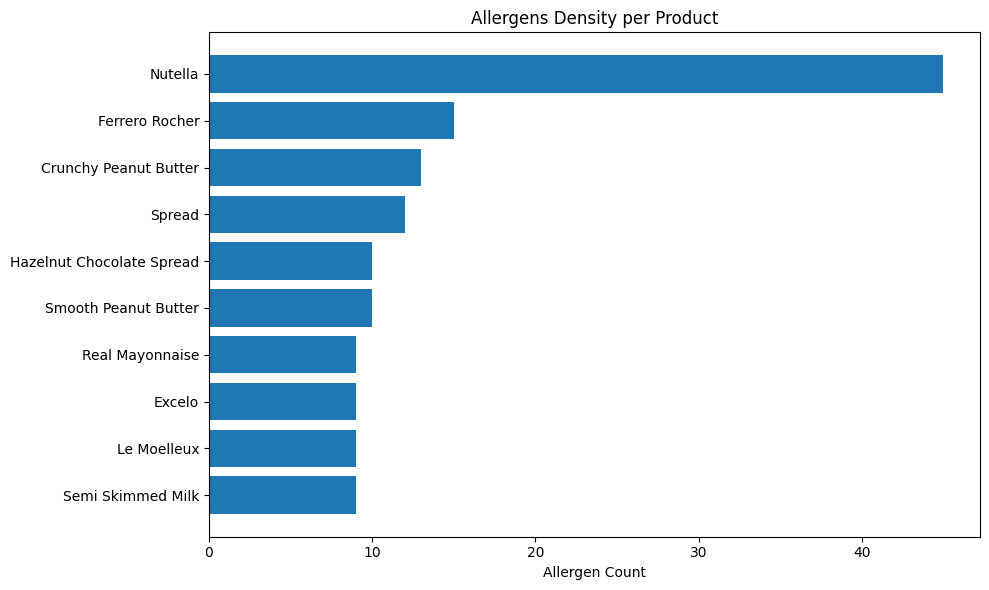

In [57]:
allergens['allergen_count'] = (
    allergens['contains_gluten'].astype(int) +
    allergens['contains_dairy'].astype(int) +
    allergens['contains_nuts'].astype(int) +
    allergens['contains_soy'].astype(int) +
    allergens['contains_eggs'].astype(int) +
    allergens['contains_fish'].astype(int)
)

# Same concept as SUM in Power BI
top_products = (
    allergens.groupby('product_name')['allergen_count']
    .sum()
    .reset_index()
    .sort_values(by='allergen_count', ascending=False)
    .head(10)
)
plt.figure(figsize=(10,6))

plt.barh(
    top_products['product_name'],
    top_products['allergen_count']
)

plt.xlabel("Allergen Count")
plt.title("Allergens Density per Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Chart 3: Top 10 Brands with the Most Safe Products

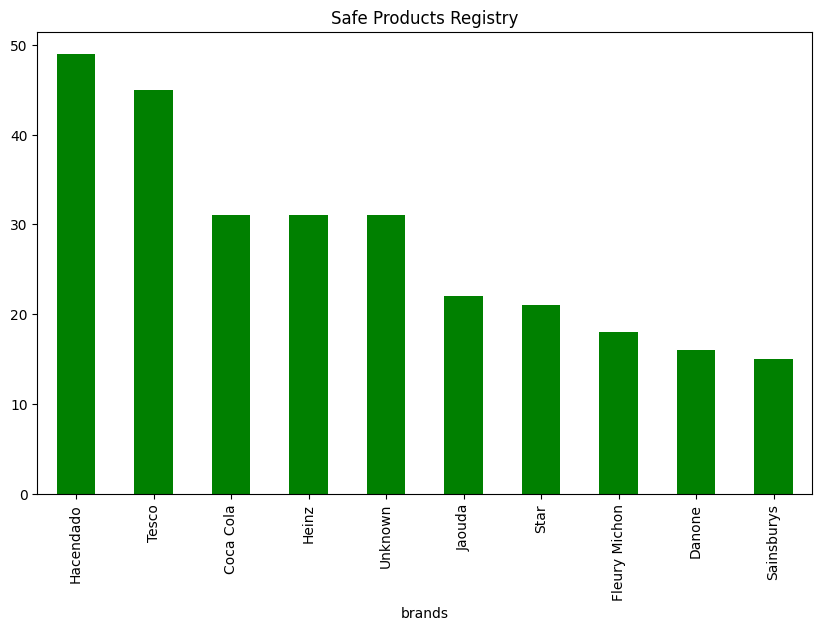

In [58]:
safe_counts = safe_products['brands'].value_counts().head(10)

plt.figure(figsize=(10,6))

safe_counts.plot(
    kind='bar',
    color='green'
)

plt.title("Safe Products Registry")

plt.show()

### Chart 4: Total Allergen Presence by Type

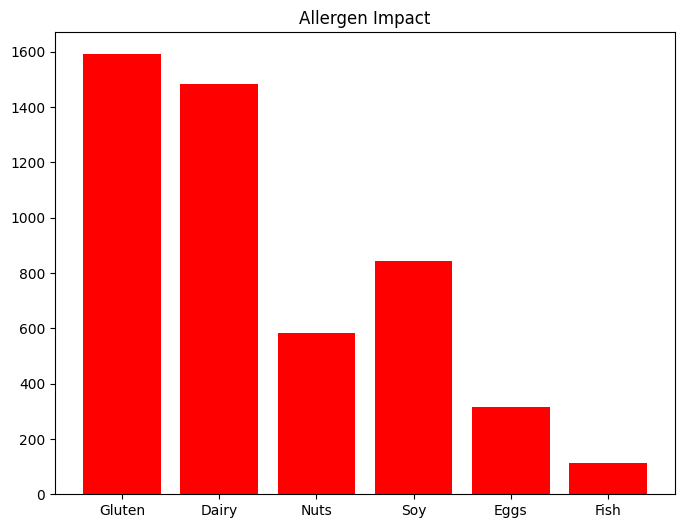

In [59]:
allergen_counts = {
    "Gluten": allergens['contains_gluten'].sum(),
    "Dairy": allergens['contains_dairy'].sum(),
    "Nuts": allergens['contains_nuts'].sum(),
    "Soy": allergens['contains_soy'].sum(),
    "Eggs": allergens['contains_eggs'].sum(),
    "Fish": allergens['contains_fish'].sum()
}

plt.figure(figsize=(8,6))

plt.bar(
    allergen_counts.keys(),
    allergen_counts.values(),
    color='red'
)

plt.title("Allergen Impact")

plt.show()

### Filter 1: Filter by Allergen Type

Change `allergen_filter` to any allergen string (e.g. `"Gluten"`, `"Milk"`).

In [60]:
allergen_filter = "Nuts"

filtered_allergen = allergens[
    allergens['allergens'].str.contains(
        allergen_filter,
        case=False,
        na=False
    )
]

display(filtered_allergen.head())

,ProductID,NutriScoreID,NovaGroupID,AllergenTypeID,AllergenCatID,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,...,contains_eggs,contains_fish,product_name,brands,nutriscore_grade,nova_group,allergens,category,subcategory,allergen_count
21,20,5,2,6,9,561.663480,41.0,24.0,35.0,30.0,...,False,False,Lindt Excellence Dark Cocoa,Lindt,E,3,"milk, nuts, sesame-seeds, soybeans",Snacks,Cocoa And Its Products,0
23,22,5,4,7,10,539.000000,30.9,10.6,57.5,56.3,...,False,False,Nutella,Ferrero,E,4,"gluten, milk, nuts, soybeans",Petit Dejeuners,Produits A Tartiner Sucres,3
33,32,5,2,11,9,578.393882,46.0,27.0,22.0,15.0,...,False,False,Excellence Cacao Rich Dark,Lindt,E,3,nuts,Snacks,Cocoa And Its Products,0
37,36,3,4,11,11,15.000000,1.1,0.1,0.0,0.0,...,False,False,Roasted Almond Without Sugar,"Danone,Alpro",B,4,nuts,Beverages And Beverages Preparations,Beverages,1
41,40,5,4,7,18,539.000000,30.9,10.6,57.5,56.3,...,False,False,Nutella,"Ferrero,Nutella",E,4,"gluten, milk, nuts, soybeans",Other,Unknown,3


### Filter 2: Filter by Product Name

Change `product_filter` to any product name substring.

In [61]:
product_filter = "Nutella"

filtered_product = allergens[
    allergens['product_name'].str.contains(
        product_filter,
        case=False,
        na=False
    )
]

display(filtered_product.head())

,ProductID,NutriScoreID,NovaGroupID,AllergenTypeID,AllergenCatID,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,...,contains_eggs,contains_fish,product_name,brands,nutriscore_grade,nova_group,allergens,category,subcategory,allergen_count
23,22,5,4,7,10,539.0,30.9,10.6,57.5,56.3,...,False,False,Nutella,Ferrero,E,4,"gluten, milk, nuts, soybeans",Petit Dejeuners,Produits A Tartiner Sucres,3
41,40,5,4,7,18,539.0,30.9,10.6,57.5,56.3,...,False,False,Nutella,"Ferrero,Nutella",E,4,"gluten, milk, nuts, soybeans",Other,Unknown,3
130,126,5,4,15,32,539.0,30.9,10.6,57.5,56.3,...,False,False,Nutella,"Ferrero, Nutella",E,4,"milk, nuts, soybeans",Breakfasts,Sweet Spreads,3
132,128,5,4,7,12,515.0,24.8,11.5,64.0,35.8,...,False,False,Crunchy Biscuits With A Creamy Nutella Center,"Nutella,Ferrero",E,4,"gluten, milk, nuts, soybeans",Snacks,Biscuits And Cakes,4
139,135,5,4,15,32,539.0,30.9,10.6,57.5,56.3,...,False,False,Nutella,"Ferrero,Nutellagg",E,4,"milk, nuts, soybeans",Breakfasts,Sweet Spreads,3


### Filter 3: Filter Products Containing Soy

In [62]:
soy_products = allergens[
    allergens['contains_soy'] == 1
]

display(soy_products.head())

,ProductID,NutriScoreID,NovaGroupID,AllergenTypeID,AllergenCatID,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,...,contains_eggs,contains_fish,product_name,brands,nutriscore_grade,nova_group,allergens,category,subcategory,allergen_count
19,18,5,4,5,8,465.0,17.50,5.5,70.00,31.50,...,True,False,Chocolate Taste Prince,Lu,E,4,"eggs, gluten, milk, soybeans",Snacks,Sweet Snacks,4
23,22,5,4,7,10,539.0,30.90,10.6,57.50,56.30,...,False,False,Nutella,Ferrero,E,4,"gluten, milk, nuts, soybeans",Petit Dejeuners,Produits A Tartiner Sucres,3
25,24,5,2,8,12,504.0,22.20,10.9,71.70,40.00,...,False,False,Tonik,Arab,E,3,"gluten, milk, soybeans",Snacks,Biscuits And Cakes,3
32,31,5,4,10,12,146.0,0.00,0.0,5.50,0.00,...,False,False,Zero Sugar Fiber Cookies,Gullon,E,4,"gluten, soybeans",Snacks,Biscuits And Cakes,2
35,34,4,4,12,15,592.0,65.21,9.8,0.22,0.05,...,True,False,Mayonnaise Recette Originale,Star,D,4,"eggs, mustard, soybeans, sulphites, sulphur-di...",Condiments,Sauces,2


---
# Dashboard 4: Cross Analysis — Nutrition × Health

### KPIs

| # | Metric | Description |
|---|--------|-------------|
| 1 | `high_health_rate` | % of merged products with health score ≥ 70 |
| 2 | `correlation` | Pearson correlation between calories and health score |
| 3 | `smart_food_ratio` | % of products that are both high-health (≥ 70) and low-calorie (< 200) |
| 4 | `avg_cal_per_health_score` | Average calories broken down by health tier (Medium / Good / Excellent) |


In [63]:
high_health_rate = (
    (merged_final['health_score'] >= 70).mean()
) * 100

print(high_health_rate)

correlation = merged_final['calories'].corr(
    merged_final['health_score']
)

print(correlation)

smart_foods = merged_final[
    (merged_final['health_score'] >= 70) &
    (merged_final['calories'] < 200)
]

smart_food_ratio = (
    len(smart_foods) / len(merged_final)
) * 100

print(smart_food_ratio)

# Ensure bin range covers 0 to 100 to avoid losing any data
merged_final['health_tier'] = pd.cut(
    merged_final['health_score'],
    bins=[0, 75, 85, 100], # Adjust range start to include lower values
    labels=['Medium', 'Good', 'Excellent'],
    include_lowest=True
)

avg_cal_per_health_tier = (
    merged_final
    .groupby('health_tier', observed=True)['calories']
    .mean()
)

print(avg_cal_per_health_tier)

29.370024229837316
0.331417894267179
2.073381793007961
health_tier
Medium    232.84657
Name: calories, dtype: float64


### Chart 1: Total Calories by Food Category

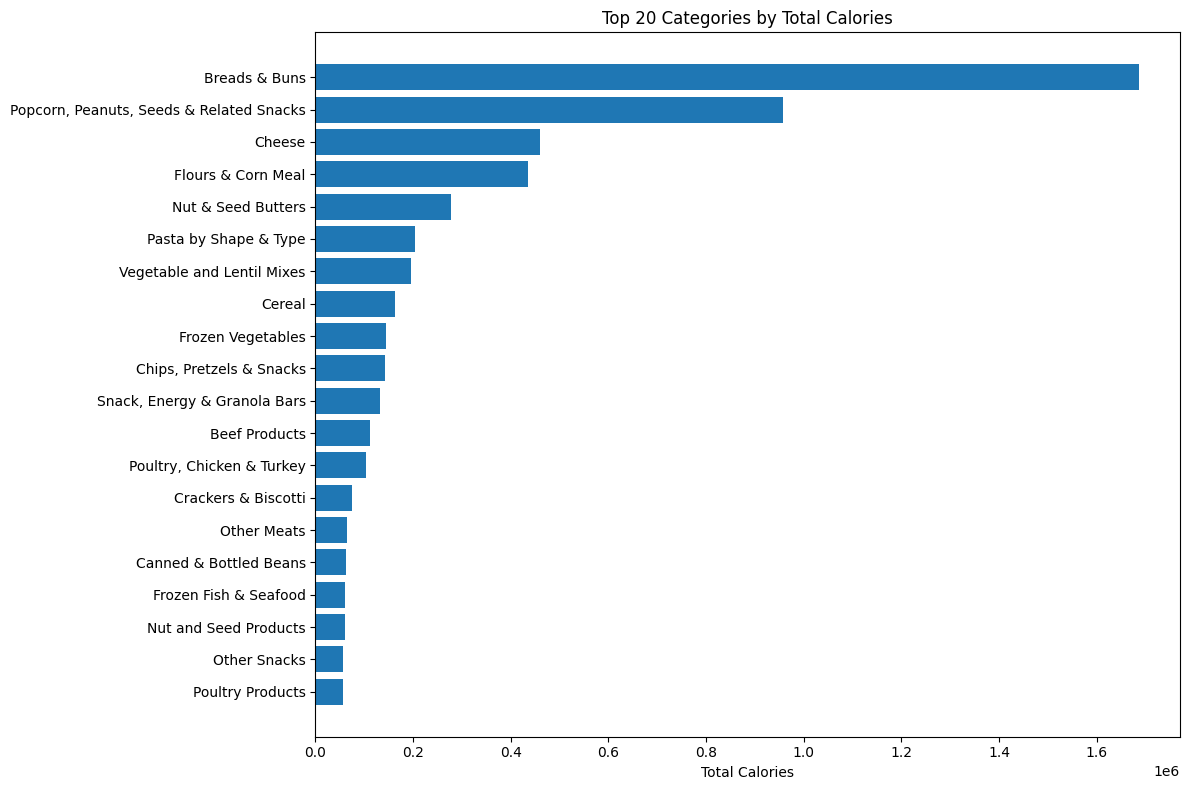

In [64]:
# Top 20 categories
top20 = (
    merged_final
    .groupby('food_category')['calories']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

plt.barh(
    top20.index,
    top20.values
)

plt.title("Top 20 Categories by Total Calories")
plt.xlabel("Total Calories")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Chart 2: Average Health Score by Food Category

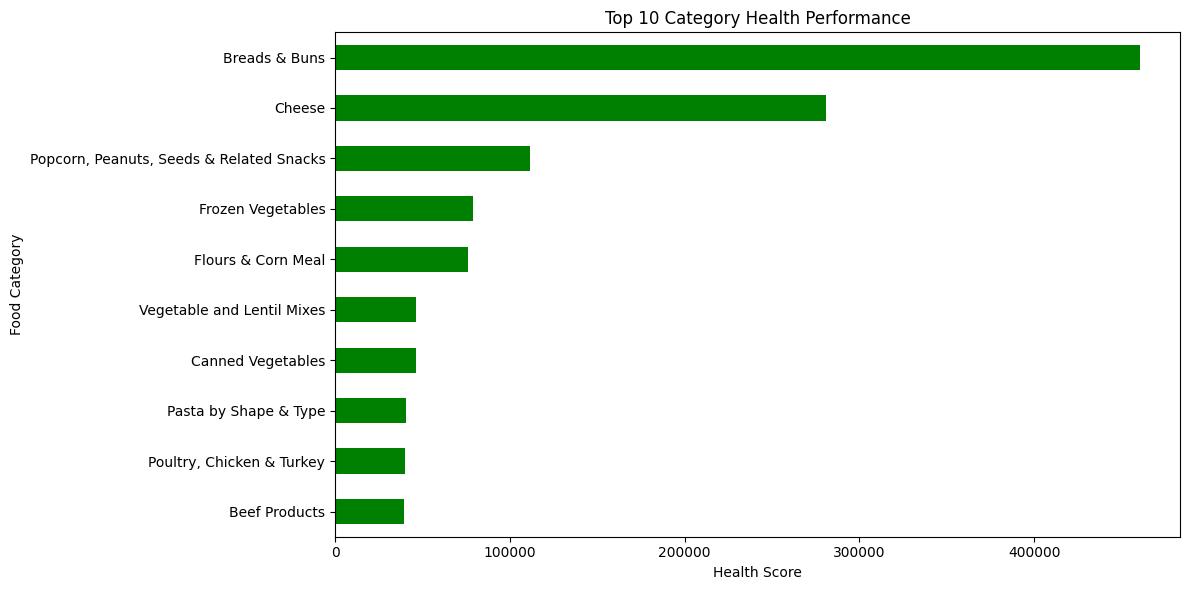

In [65]:
# Top 10 categories by health score

health_performance = (
    merged_final
    .groupby('food_category')['health_score']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

health_performance.plot(
    kind='barh',
    color='green'
)

plt.title("Top 10 Category Health Performance")
plt.xlabel("Health Score")
plt.ylabel("Food Category")

# Higher values appear at top
plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Chart 3: Average Health Score by Calorie Range

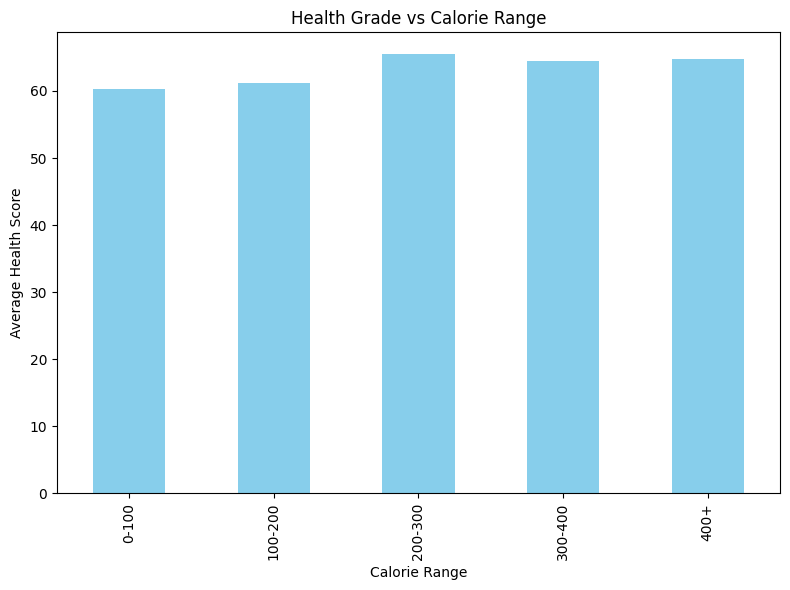

In [66]:
merged_final['calorie_range'] = pd.cut(
    merged_final['calories'],
    bins=[0,100,200,300,400,1000],
    labels=['0-100','100-200','200-300','300-400','400+']
)

grade_chart = (
    merged_final
    .groupby('calorie_range')['health_score']
    .mean()
)

plt.figure(figsize=(8,6))

grade_chart.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Health Grade vs Calorie Range")
plt.xlabel("Calorie Range")
plt.ylabel("Average Health Score")

plt.tight_layout()

plt.show()

### Filters

**Filter 1** — by `food_category`: change `category_filter` to any category.  
**Filter 2** — by health tier: currently shows `'High'` tier. Change the label to `'Low'` or `'Medium'` as needed.

In [67]:

# Filter 1 : food_category

category_filter = "Snacks"

filtered_category = merged_final[
    merged_final['food_category'] == category_filter
]

display(filtered_category.head())


# Filter 2 : health_score bins

merged_final['health_bins'] = pd.cut(
    merged_final['health_score'],
    bins=[0,40,70,100],
    labels=['Low','Medium','High']
)

filtered_health = merged_final[
    merged_final['health_bins'] == 'High'
]

display(filtered_health.head())


,food_name,calories,health_score,food_type,food_category,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,health_tier,calorie_range
1634,formulated bar mars snackfood us snickers mara...,377.3,65,Snacks & Sweets,Snacks,22.4,8.99,51.7,10.5,22.7,333.0,Medium,300-400
1635,formulated bar mars snackfood us snickers mara...,386.0,65,Snacks & Sweets,Snacks,21.9,10.80,50.3,6.7,28.7,383.0,Medium,300-400
1636,formulated bar mars snackfood us snickers mara...,381.0,65,Snacks & Sweets,Snacks,22.5,7.87,55.1,11.0,26.3,318.0,Medium,300-400
1637,formulated bar power bar chocolate,363.2,65,Snacks & Sweets,Snacks,14.2,3.11,69.6,5.7,30.1,308.0,Medium,300-400
1638,formulated bar south beach protein bar,411.6,65,Snacks & Sweets,Snacks,30.3,15.20,38.4,7.3,15.2,436.0,Medium,400+


,food_name,calories,health_score,food_type,food_category,protein_g,fat_g,carbs_g,fiber_g,sugar_g,sodium_mg,health_tier,calorie_range,health_bins
933,cereals ready to eat general mills cheerios,372.0,75,Other,Breakfast Cereals,12.4,6.6,73.2,10.1,4.50,497.0,Medium,300-400,High
1188,chives freeze dried,311.0,75,Vegetables,Vegetables and Vegetable Products,21.2,3.5,64.3,26.2,1.60,70.0,Medium,300-400,High
1894,leeks bulb and lower leaf portion freeze dried,321.0,75,Vegetables,Vegetables and Vegetable Products,15.2,2.1,74.6,10.4,1.60,35.0,Medium,300-400,High
1991,natto,227.4,75,Other,Legumes and Legume Products,19.4,11.0,12.7,5.4,4.89,7.0,Medium,200-300,High
2090,parsley freeze dried,1130.0,75,Vegetables,Vegetables and Vegetable Products,31.3,5.2,42.4,32.7,1.60,391.0,Medium,NaN,High


---
# Dashboard 5: NOVA Group & Nutri-Score Quality Analysis

### KPIs

| # | Metric | Description |
|---|--------|-------------|
| 1 | `nutriscore_a_ratio` | % of products with Nutri-Score grade A (best quality) |
| 2 | `high_nova_ratio` | % of products with NOVA group ≥ 4 (ultra-processed) |
| 3 | `avg_energy_kcal` | Average energy (kcal per 100g) |
| 4 | `avg_nova_protein` | Average protein (g per 100g) |
| 5 | `low_quality_ratio` | % of products with Nutri-Score D or E (poor quality) |

In [68]:

# 1- Nutriscore_A_Ratio

nutriscore_a_ratio = (
    (allergens['nutriscore_grade'] == 'A').mean()
) 


# 2- High_NOVA_Ratio

high_nova_ratio = (
    (allergens['nova_group'] >= 4).mean()
) 


# 3- Avg_Energy_kcal

avg_energy_kcal = allergens['energy_kcal'].mean()


# 4- Avg_Nova_Protein

avg_nova_protein = allergens['proteins_100g'].mean()


# 5- Low_Quality_Ratio

low_quality_ratio = (
    (
        (allergens['nutriscore_grade'] == 'D') |
        (allergens['nutriscore_grade'] == 'E')
    ).mean()
) 

print(nutriscore_a_ratio)
print(high_nova_ratio)
print(avg_energy_kcal)
print(avg_nova_protein)
print(low_quality_ratio)


0.16808769792935443
0.5314656922452294
294.41642913990256
7.090649051732644
0.3808363784003248


### Chart 1: Product Count by Nutri-Score Grade

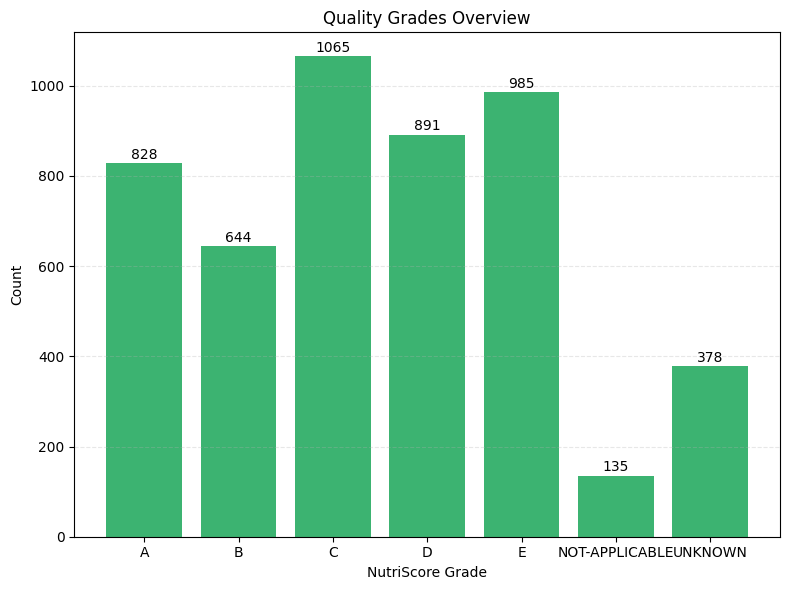

In [69]:
import matplotlib.pyplot as plt

grade_counts = (
    allergens['nutriscore_grade']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,6))

bars = plt.bar(
    grade_counts.index.astype(str),
    grade_counts.values,
    color='mediumseagreen'
)

# Write values above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,
        f'{int(height)}',
        ha='center'
    )

plt.title("Quality Grades Overview")
plt.xlabel("NutriScore Grade")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

### Chart 2: Product Distribution by NOVA Group (Pie Chart)

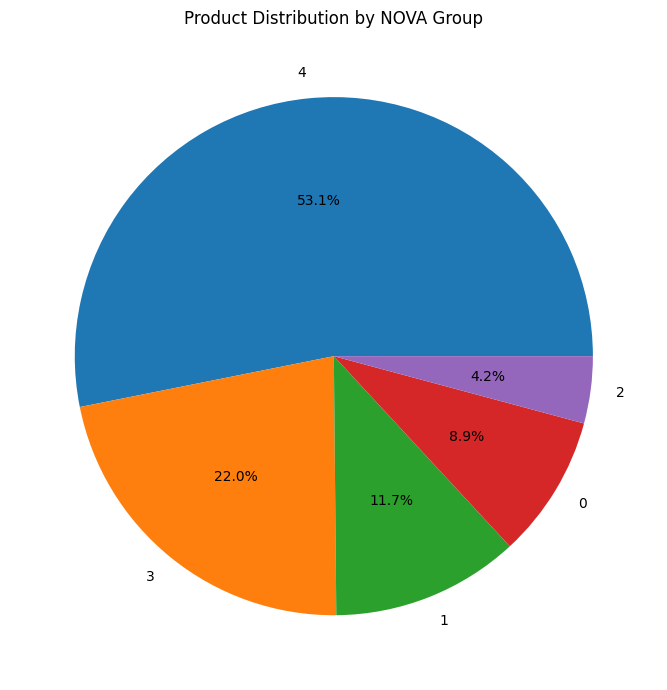

In [70]:
nova_counts = allergens['nova_group'].value_counts()

plt.figure(figsize=(7,7))

nova_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Product Distribution by NOVA Group")

plt.ylabel("")

plt.tight_layout()

plt.show()

### Chart 3: Allergen Presence by NOVA Processing Level

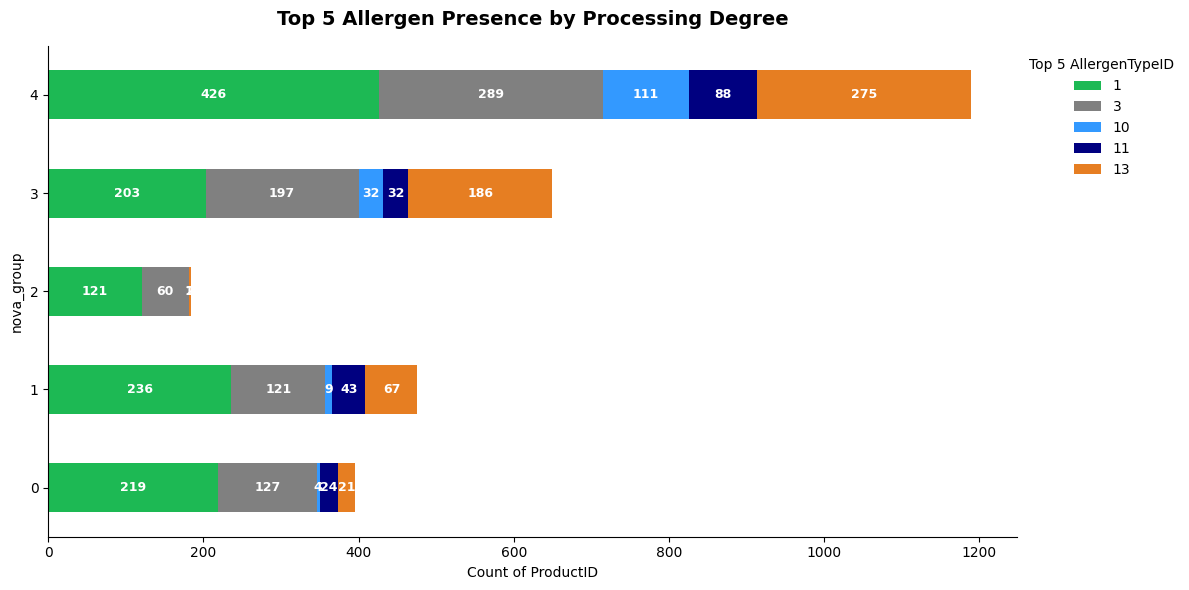

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify Top 5 AllergenTypeIDs based on product count
top_5_allergens_ids = (
    allergens['AllergenTypeID']
    .value_counts()
    .head(5)
    .index
)

# 2. Filter original data to include only Top 5
allergens_filtered = allergens[allergens['AllergenTypeID'].isin(top_5_allergens_ids)]

# 3. Prepare Pivot Table for visualization
nova_pivoted = (
    allergens_filtered.groupby(['nova_group', 'AllergenTypeID'])
    .size()
    .unstack(fill_value=0)
)

# 4. Draw chart (same format as before)
ax = nova_pivoted.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 6),
    # Use 5 colors only for the Top 5
    color=['#1DB954', '#808080', '#3399FF', '#000080', '#E67E22'] 
)

# 5. Format and add numbers
plt.title("Top 5 Allergen Presence by Processing Degree", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Count of ProductID")
plt.ylabel("nova_group")

for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

ax.legend(title="Top 5 AllergenTypeID", bbox_to_anchor=(1.0, 1.0), frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Chart 4: Energy vs. Protein Density Scatter Plot

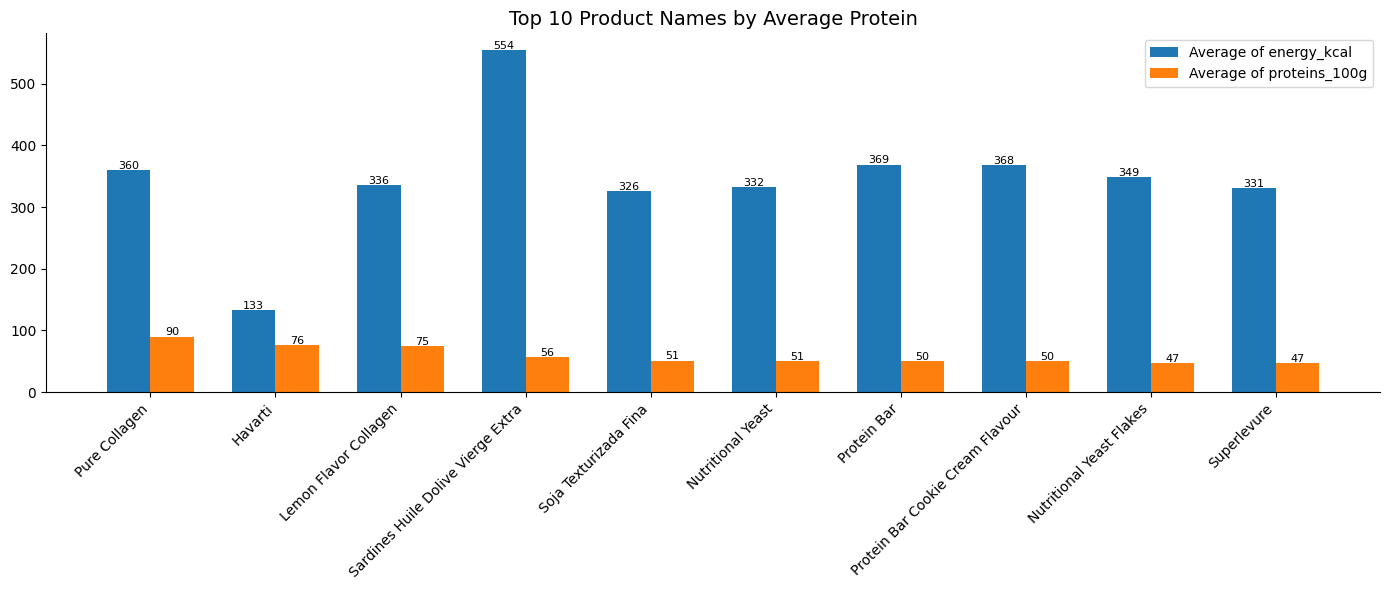

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================================
# TOP 10 product_name by avg protein
# ================================

# Group and calculate averages
top10 = (
    allergens.groupby("product_name", as_index=False)
    .agg({
        "proteins_100g": "mean",
        "energy_kcal": "mean"
    })
    .sort_values(by="proteins_100g", ascending=False)
    .head(10)
)

# Sort for better visualization
top10 = top10.sort_values(by="proteins_100g", ascending=False)

# X positions
x = np.arange(len(top10))
width = 0.35

# Figure
fig, ax = plt.subplots(figsize=(14, 6))

# Bars
bars1 = ax.bar(
    x - width/2,
    top10["energy_kcal"],
    width,
    label="Average of energy_kcal"
)

bars2 = ax.bar(
    x + width/2,
    top10["proteins_100g"],
    width,
    label="Average of proteins_100g"
)

# Labels above bars
for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 2,
        f"{h:.0f}",
        ha='center',
        fontsize=8
    )

for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 2,
        f"{h:.0f}",
        ha='center',
        fontsize=8
    )

# Chart appearance
ax.set_title("Top 10 Product Names by Average Protein", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(
    top10["product_name"],
    rotation=45,
    ha='right'
)

ax.legend()

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Filters

**Filter 1** — by `nova_group`: change `nova_filter` to 1, 2, 3, or 4.  
**Filter 2** — by `nutriscore_grade`: change `nutri_filter` to `'A'`, `'B'`, `'C'`, `'D'`, or `'E'`.  
**Filter 3** — by allergen type: change `allergen_filter` to any allergen string.

In [73]:

# Filter 1 : nova_group

nova_filter = 4

filtered_nova = allergens[
    allergens['nova_group'] == nova_filter
]

display(filtered_nova.head())


# Filter 2 : nutriscore_grade

nutri_filter = "A"

filtered_nutri = allergens[
    allergens['nutriscore_grade'] == nutri_filter
]

display(filtered_nutri.head())


# Filter 3 : allergens

allergen_filter = "Gluten"

filtered_allergen = allergens[
    allergens['allergens'].str.contains(
        allergen_filter,
        case=False,
        na=False
    )
]

display(filtered_allergen.head())


,ProductID,NutriScoreID,NovaGroupID,AllergenTypeID,AllergenCatID,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,...,contains_eggs,contains_fish,product_name,brands,nutriscore_grade,nova_group,allergens,category,subcategory,allergen_count
9,9,4,4,3,2,235.0,21.0,15.0,3.5,0.0,...,False,False,Jben,Jaouda,D,4,milk,Dairies,Fermented Milk Products,1
13,12,5,4,4,5,260.0,0.5,0.1,30.0,1.2,...,False,False,Yeast Extract,Marmite,E,4,"celery, gluten",Spreads,Yeast Extract Spreads,1
17,16,6,4,1,7,13.3,0.0,0.0,3.3,3.3,...,False,False,Coca Cola Original Taste,Coca Cola,C,4,unknown,Beverages And Beverages Preparations,Carbonated Drinks,0
19,18,5,4,5,8,465.0,17.5,5.5,70.0,31.5,...,True,False,Chocolate Taste Prince,Lu,E,4,"eggs, gluten, milk, soybeans",Snacks,Sweet Snacks,4
23,22,5,4,7,10,539.0,30.9,10.6,57.5,56.3,...,False,False,Nutella,Ferrero,E,4,"gluten, milk, nuts, soybeans",Petit Dejeuners,Produits A Tartiner Sucres,3


,ProductID,NutriScoreID,NovaGroupID,AllergenTypeID,AllergenCatID,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,...,contains_eggs,contains_fish,product_name,brands,nutriscore_grade,nova_group,allergens,category,subcategory,allergen_count
0,1,1,1,1,1,0.0,0.0,0.0000,4.2,1.4,...,False,False,Sidi Ali,Sidi Ali,A,0,unknown,Beverages And Beverages Preparations,Waters,0
2,1,1,3,1,1,40.0,0.2,0.0432,5.4,4.2,...,False,False,Sidi Ali,Sidi Ali,A,1,unknown,Beverages And Beverages Preparations,Waters,0
3,3,1,3,1,1,40.0,0.2,0.0432,5.4,4.2,...,False,False,Ice Tea Pche,Sidi Ali,A,1,unknown,Beverages And Beverages Preparations,Waters,0
4,4,1,1,1,1,0.0,0.0,0.0000,0.0,0.0,...,False,False,Aquafina,Aquafina,A,0,unknown,Beverages And Beverages Preparations,Waters,0
6,6,1,3,1,1,0.0,0.0,0.0000,0.0,0.0,...,False,False,Eau De Source,Cristaline,A,1,unknown,Beverages And Beverages Preparations,Waters,0


,ProductID,NutriScoreID,NovaGroupID,AllergenTypeID,AllergenCatID,energy_kcal,fat_100g,saturated_fat_100g,carbs_100g,sugars_100g,...,contains_eggs,contains_fish,product_name,brands,nutriscore_grade,nova_group,allergens,category,subcategory,allergen_count
13,12,5,4,4,5,260.0,0.5,0.1,30.0,1.2,...,False,False,Yeast Extract,Marmite,E,4,"celery, gluten",Spreads,Yeast Extract Spreads,1
19,18,5,4,5,8,465.0,17.5,5.5,70.0,31.5,...,True,False,Chocolate Taste Prince,Lu,E,4,"eggs, gluten, milk, soybeans",Snacks,Sweet Snacks,4
23,22,5,4,7,10,539.0,30.9,10.6,57.5,56.3,...,False,False,Nutella,Ferrero,E,4,"gluten, milk, nuts, soybeans",Petit Dejeuners,Produits A Tartiner Sucres,3
25,24,5,2,8,12,504.0,22.2,10.9,71.7,40.0,...,False,False,Tonik,Arab,E,3,"gluten, milk, soybeans",Snacks,Biscuits And Cakes,3
28,27,6,4,9,12,467.0,18.0,2.0,64.0,17.0,...,False,False,Sesame,Gerbl,C,4,"eggs, gluten, lupin, milk, sesame-seeds, soybeans",Snacks,Biscuits And Cakes,1
